**ARDYINA MARTAEKA LATYFA**

2304020193

UJIAN TENGAH SEMESTER
DATA MINING

# **IMPORT LIBRARY**

In [1]:
# ================================
# IMPORT LIBRARY
# ================================

# Pengolahan data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

Pada tahap ini dilakukan import beberapa library yang akan digunakan selama proses data mining. Library pandas digunakan untuk membaca dan mengolah dataset dalam bentuk tabel (DataFrame), sedangkan numpy digunakan untuk operasi numerik dan perhitungan matematika. Library matplotlib dan seaborn digunakan untuk membuat visualisasi data seperti histogram, heatmap, boxplot, dan grafik lainnya agar pola data lebih mudah dipahami.

# **LOAD DATASET**

In [2]:
# ================================
# LOAD DATASET
# ================================

# Upload file di Google Colab
from google.colab import files
uploaded = files.upload()

Saving data_testing.csv to data_testing.csv
Saving data_training.csv to data_training.csv


Pada tahap ini dataset berhasil diunggah ke Google Colab menggunakan fitur upload file. Dataset yang digunakan terdiri dari:

- data training digunakan untuk melatih model,

- data testing digunakan untuk prediksi akhir.

Tahap upload penting agar dataset dapat dibaca dan diproses menggunakan Python pada Google Colab.

## **MEMBACA DATASET**

In [3]:
# Membaca dataset training dan testing
train_df = pd.read_csv('data_training.csv')
test_df = pd.read_csv('data_testing.csv')

Dataset training dan testing berhasil dibaca menggunakan pd.read_csv() dan disimpan dalam bentuk DataFrame. Dengan DataFrame, data dapat diolah lebih mudah karena memiliki struktur tabel yang terdiri dari baris dan kolom.

Data training nantinya digunakan untuk proses pembelajaran model machine learning, sedangkan data testing digunakan untuk menghasilkan prediksi kualitas wine.

### **MENAMPILKAN DATA AWAL**

In [7]:
# Menampilkan 5 data pertama
train_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Pada tahap ini ditampilkan 5 data pertama dari dataset training menggunakan head(). Hasil ini membantu memahami struktur dataset seperti:

nama kolom,
isi data,
dan format data pada tiap fitur.

Tahap ini juga digunakan untuk memastikan bahwa dataset berhasil dibaca dengan benar tanpa error.

## **VISUALISASI DATA SEBELUM CLEANING**

Shape Data Training : (857, 13)
Shape Data Testing : (286, 12)


5 DATA PERTAMA


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918




INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


TIPE DATA SETIAP KOLOM
fixed acidity           float64
v

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


JUMLAH MISSING VALUE
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


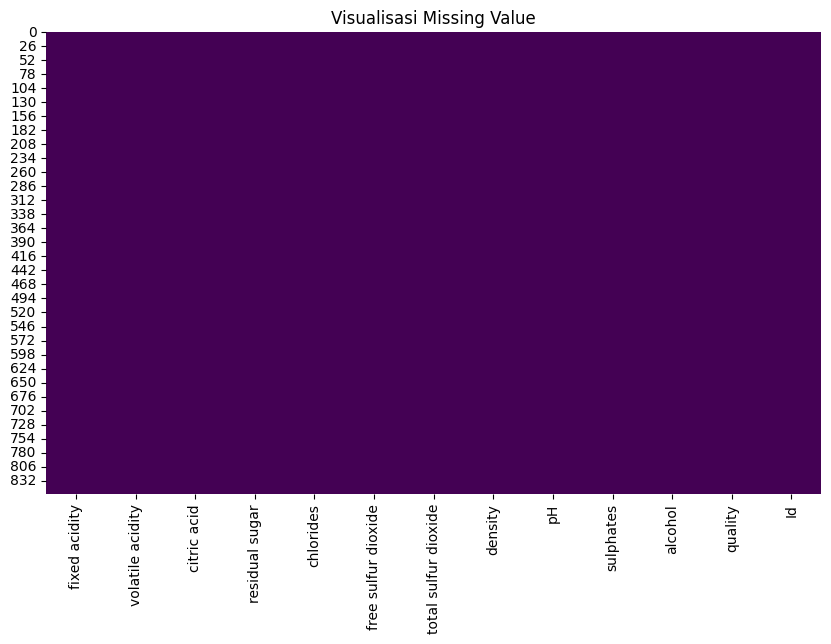

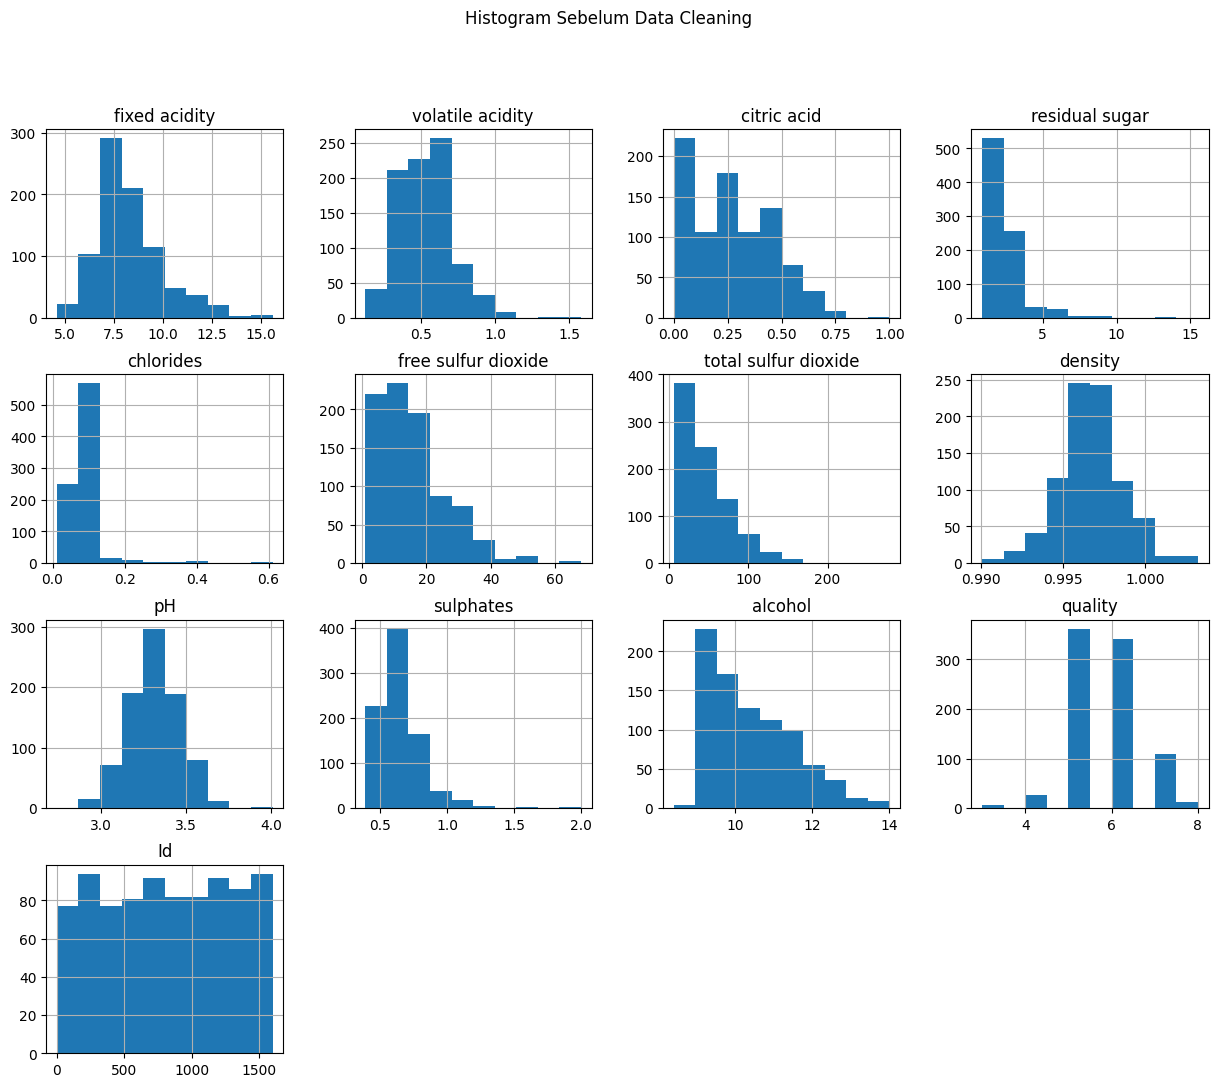

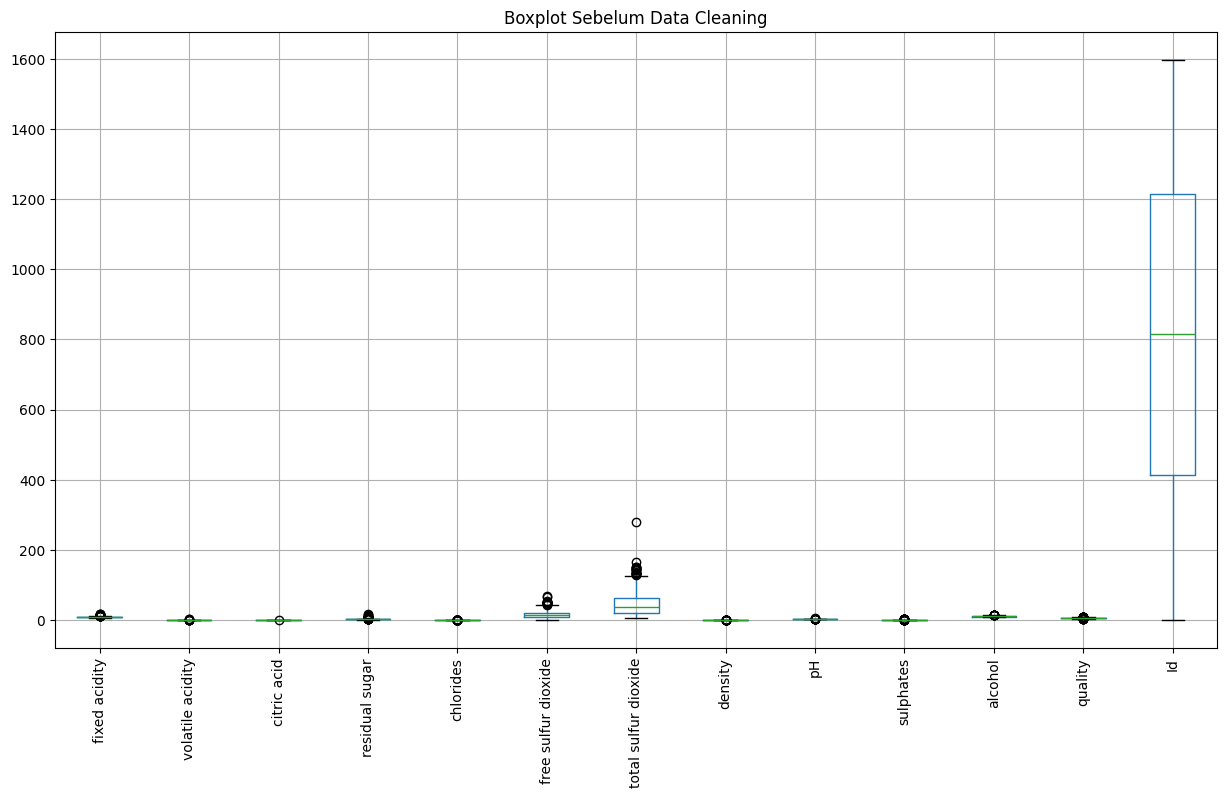

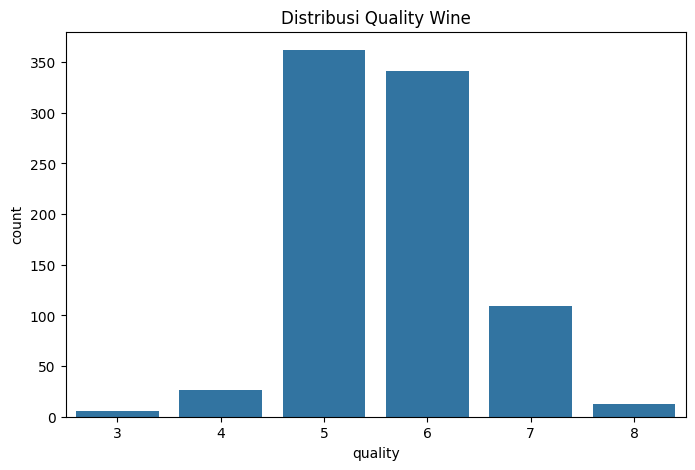

In [17]:
# ================================
# VISUALISASI DATA SEBELUM CLEANING
# ================================

# ================================
# MELIHAT UKURAN DATASET
# ================================

print("Shape Data Training :", train_df.shape)
print("Shape Data Testing :", test_df.shape)

print("\n")

# ================================
# MELIHAT 5 DATA PERTAMA
# ================================

print("5 DATA PERTAMA")

display(train_df.head())

print("\n")

# ================================
# INFORMASI DATASET
# ================================

print("INFORMASI DATASET")

train_df.info()

print("\n")

# ================================
# TIPE DATA
# ================================

print("TIPE DATA SETIAP KOLOM")

print(train_df.dtypes)

print("\n")

# ================================
# STATISTIK DESKRIPTIF
# ================================

print("STATISTIK DESKRIPTIF")

display(train_df.describe())

# ================================
# MISSING VALUE
# ================================

print("JUMLAH MISSING VALUE")

print(train_df.isnull().sum())

# ================================
# VISUALISASI MISSING VALUE
# ================================

plt.figure(figsize=(10,6))

sns.heatmap(
    train_df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Visualisasi Missing Value')

plt.show()

# ================================
# HISTOGRAM
# ================================

train_df.hist(figsize=(15,12))

plt.suptitle('Histogram Sebelum Data Cleaning')

plt.show()

# ================================
# BOXPLOT
# ================================

plt.figure(figsize=(15,8))

train_df.boxplot()

plt.xticks(rotation=90)

plt.title('Boxplot Sebelum Data Cleaning')

plt.show()

# ================================
# DISTRIBUSI TARGET QUALITY
# ================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='quality',
    data=train_df
)

plt.title('Distribusi Quality Wine')

plt.show()

Tahap visualisasi awal dilakukan untuk memahami kondisi dataset sebelum proses data cleaning.

- Hasil shape menunjukkan dataset memiliki 1143 baris dan 13 kolom, sehingga jumlah data cukup untuk proses machine learning.

- Hasil info() menunjukkan sebagian besar fitur bertipe numerik (float64 dan int64) serta terdapat beberapa missing value yang perlu dibersihkan sebelum modeling.

- Hasil describe() menunjukkan perbedaan nilai minimum, maksimum, rata-rata, dan standar deviasi pada tiap fitur. Hal ini menunjukkan rentang data cukup beragam sehingga diperlukan feature scaling.

- Heatmap missing value menunjukkan terdapat beberapa data kosong pada dataset. Oleh karena itu dilakukan proses cleaning menggunakan pengisian nilai rata-rata.

- Histogram menunjukkan distribusi data tiap fitur berbeda-beda, dimana beberapa fitur memiliki distribusi yang tidak merata.

- Boxplot menunjukkan adanya beberapa outlier pada dataset, namun algoritma Random Forest masih cukup baik dalam menangani outlier.

- Countplot quality menunjukkan distribusi kategori kualitas wine tidak sepenuhnya seimbang karena beberapa kategori memiliki jumlah data lebih banyak dibanding kategori lainnya.

Berdasarkan hasil visualisasi awal, dataset memerlukan proses data cleaning dan preprocessing sebelum dilakukan modeling machine learning.

## **DATA UNDERSTANDING**

In [8]:
# ================================
# DATA UNDERSTANDING
# ================================

# Melihat ukuran dataset
print("Shape Data Training :", train_df.shape)
print("Shape Data Testing :", test_df.shape)

Shape Data Training : (857, 13)
Shape Data Testing : (286, 12)


Pada tahap ini dilakukan pemahaman lebih lanjut terhadap dataset. Informasi mengenai ukuran dataset dan struktur data membantu mengetahui kompleksitas data yang akan digunakan dalam proses machine learning.

Tahap data understanding penting agar proses preprocessing dan modeling dapat dilakukan dengan tepat sesuai karakteristik dataset.

# **INFORMASI DATASET**

In [10]:
# Melihat informasi dataset
train_df.info()
# Statistik deskriptif
train_df.describe()
# Mengecek tipe data
train_df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


Tahap ini memberikan informasi detail mengenai dataset seperti:

tipe data tiap variabel,
jumlah data,
statistik deskriptif,
dan distribusi nilai.

Dari hasil statistik deskriptif dapat diketahui:

rata-rata tiap fitur,
persebaran data,
nilai minimum,
dan nilai maksimum.

Informasi ini membantu memahami karakteristik data sebelum dilakukan preprocessing.

## **DATA CLEANING**

In [11]:
# ================================
# DATA CLEANING
# ================================

# Mengecek missing value
train_df.isnull().sum()
# Mengecek missing value data testing
test_df.isnull().sum()
# Mengatasi missing value
train_df = train_df.fillna(train_df.mean(numeric_only=True))
test_df = test_df.fillna(test_df.mean(numeric_only=True))
# Cek kembali missing value
train_df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Pada tahap ini dilakukan pengecekan missing value pada dataset training dan testing. Jika terdapat data kosong maka missing value diisi menggunakan nilai rata-rata dari masing-masing kolom numerik.

Metode ini digunakan karena rata-rata dianggap mampu mewakili data numerik tanpa mengubah distribusi data secara signifikan.

Setelah proses cleaning selesai, dataset menjadi lebih bersih dan siap digunakan untuk proses machine learning.

## **VISUALISASI DATA SETELAH CLEANING**

MISSING VALUE SETELAH CLEANING
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


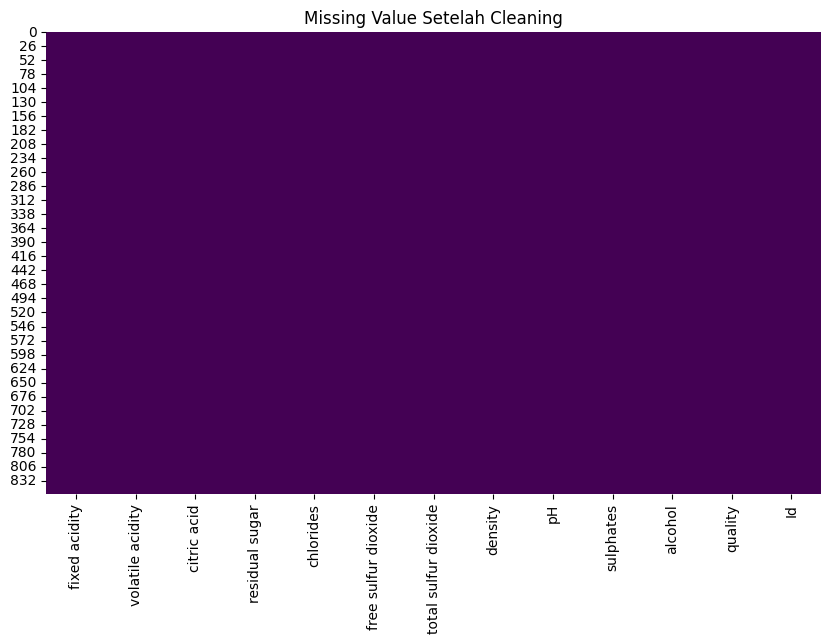

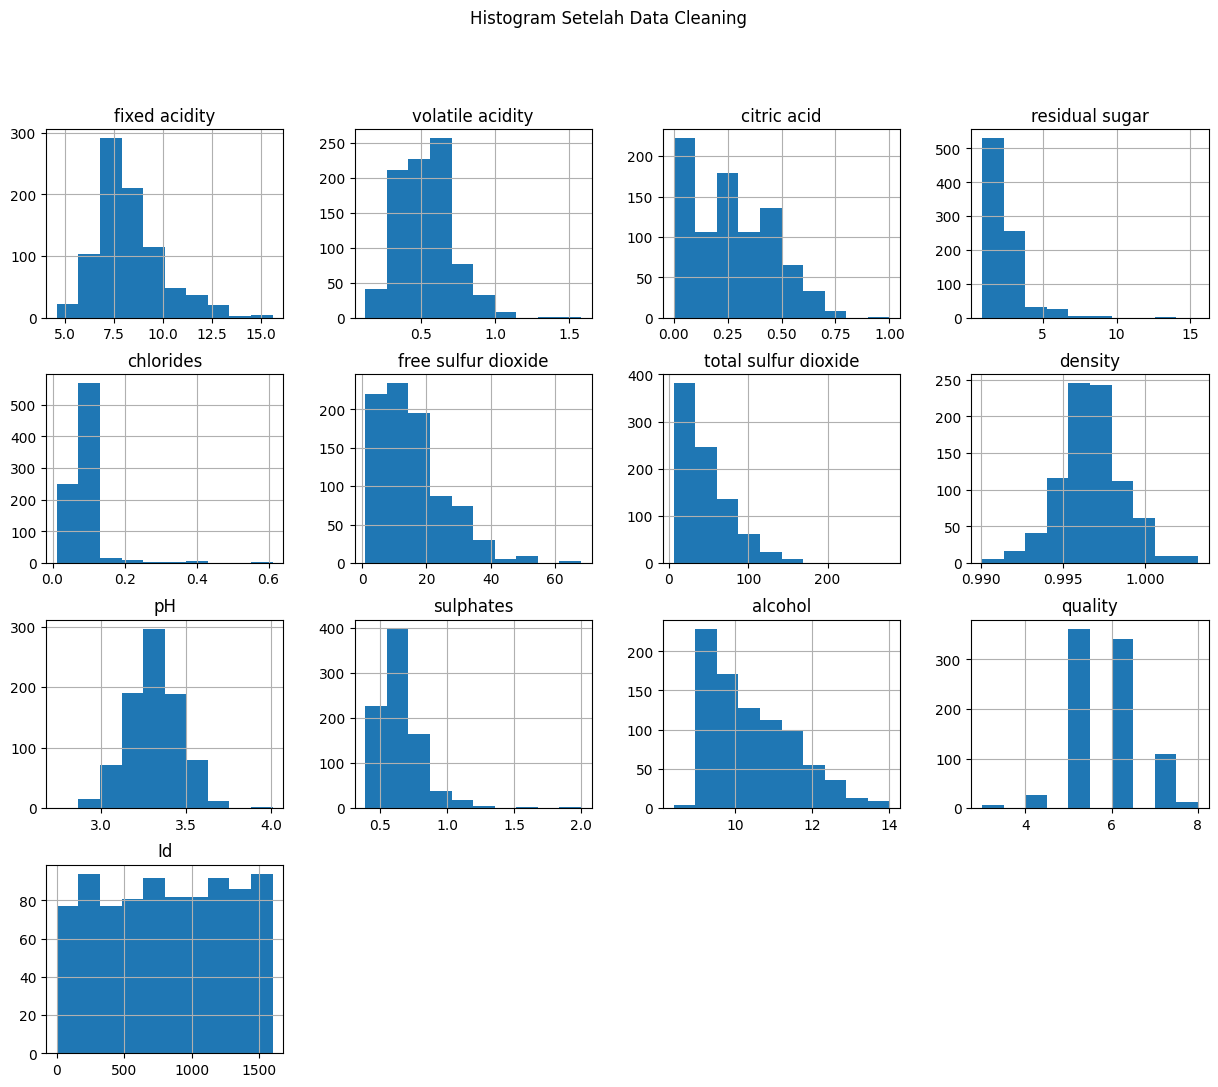

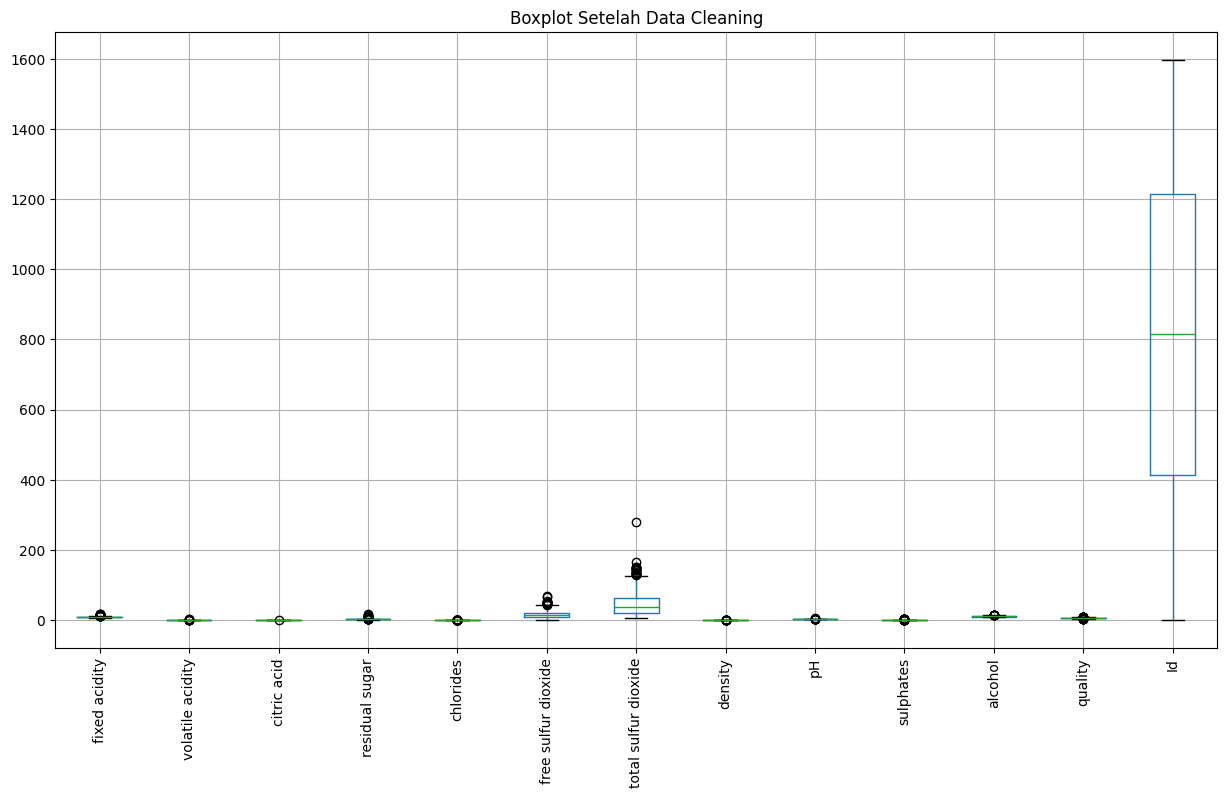

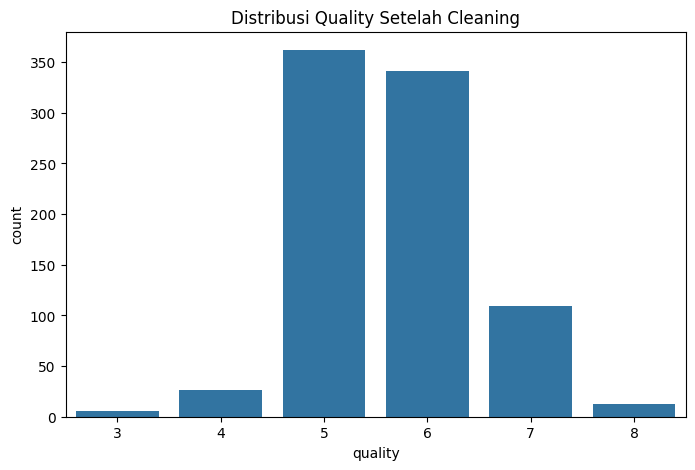

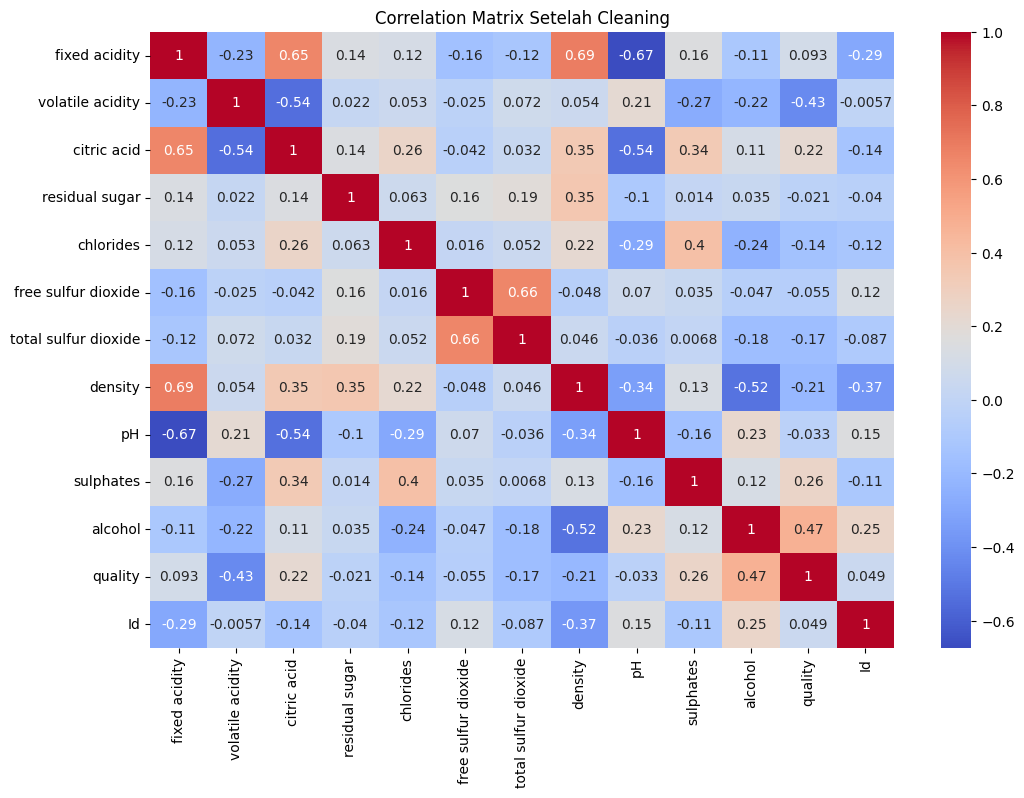

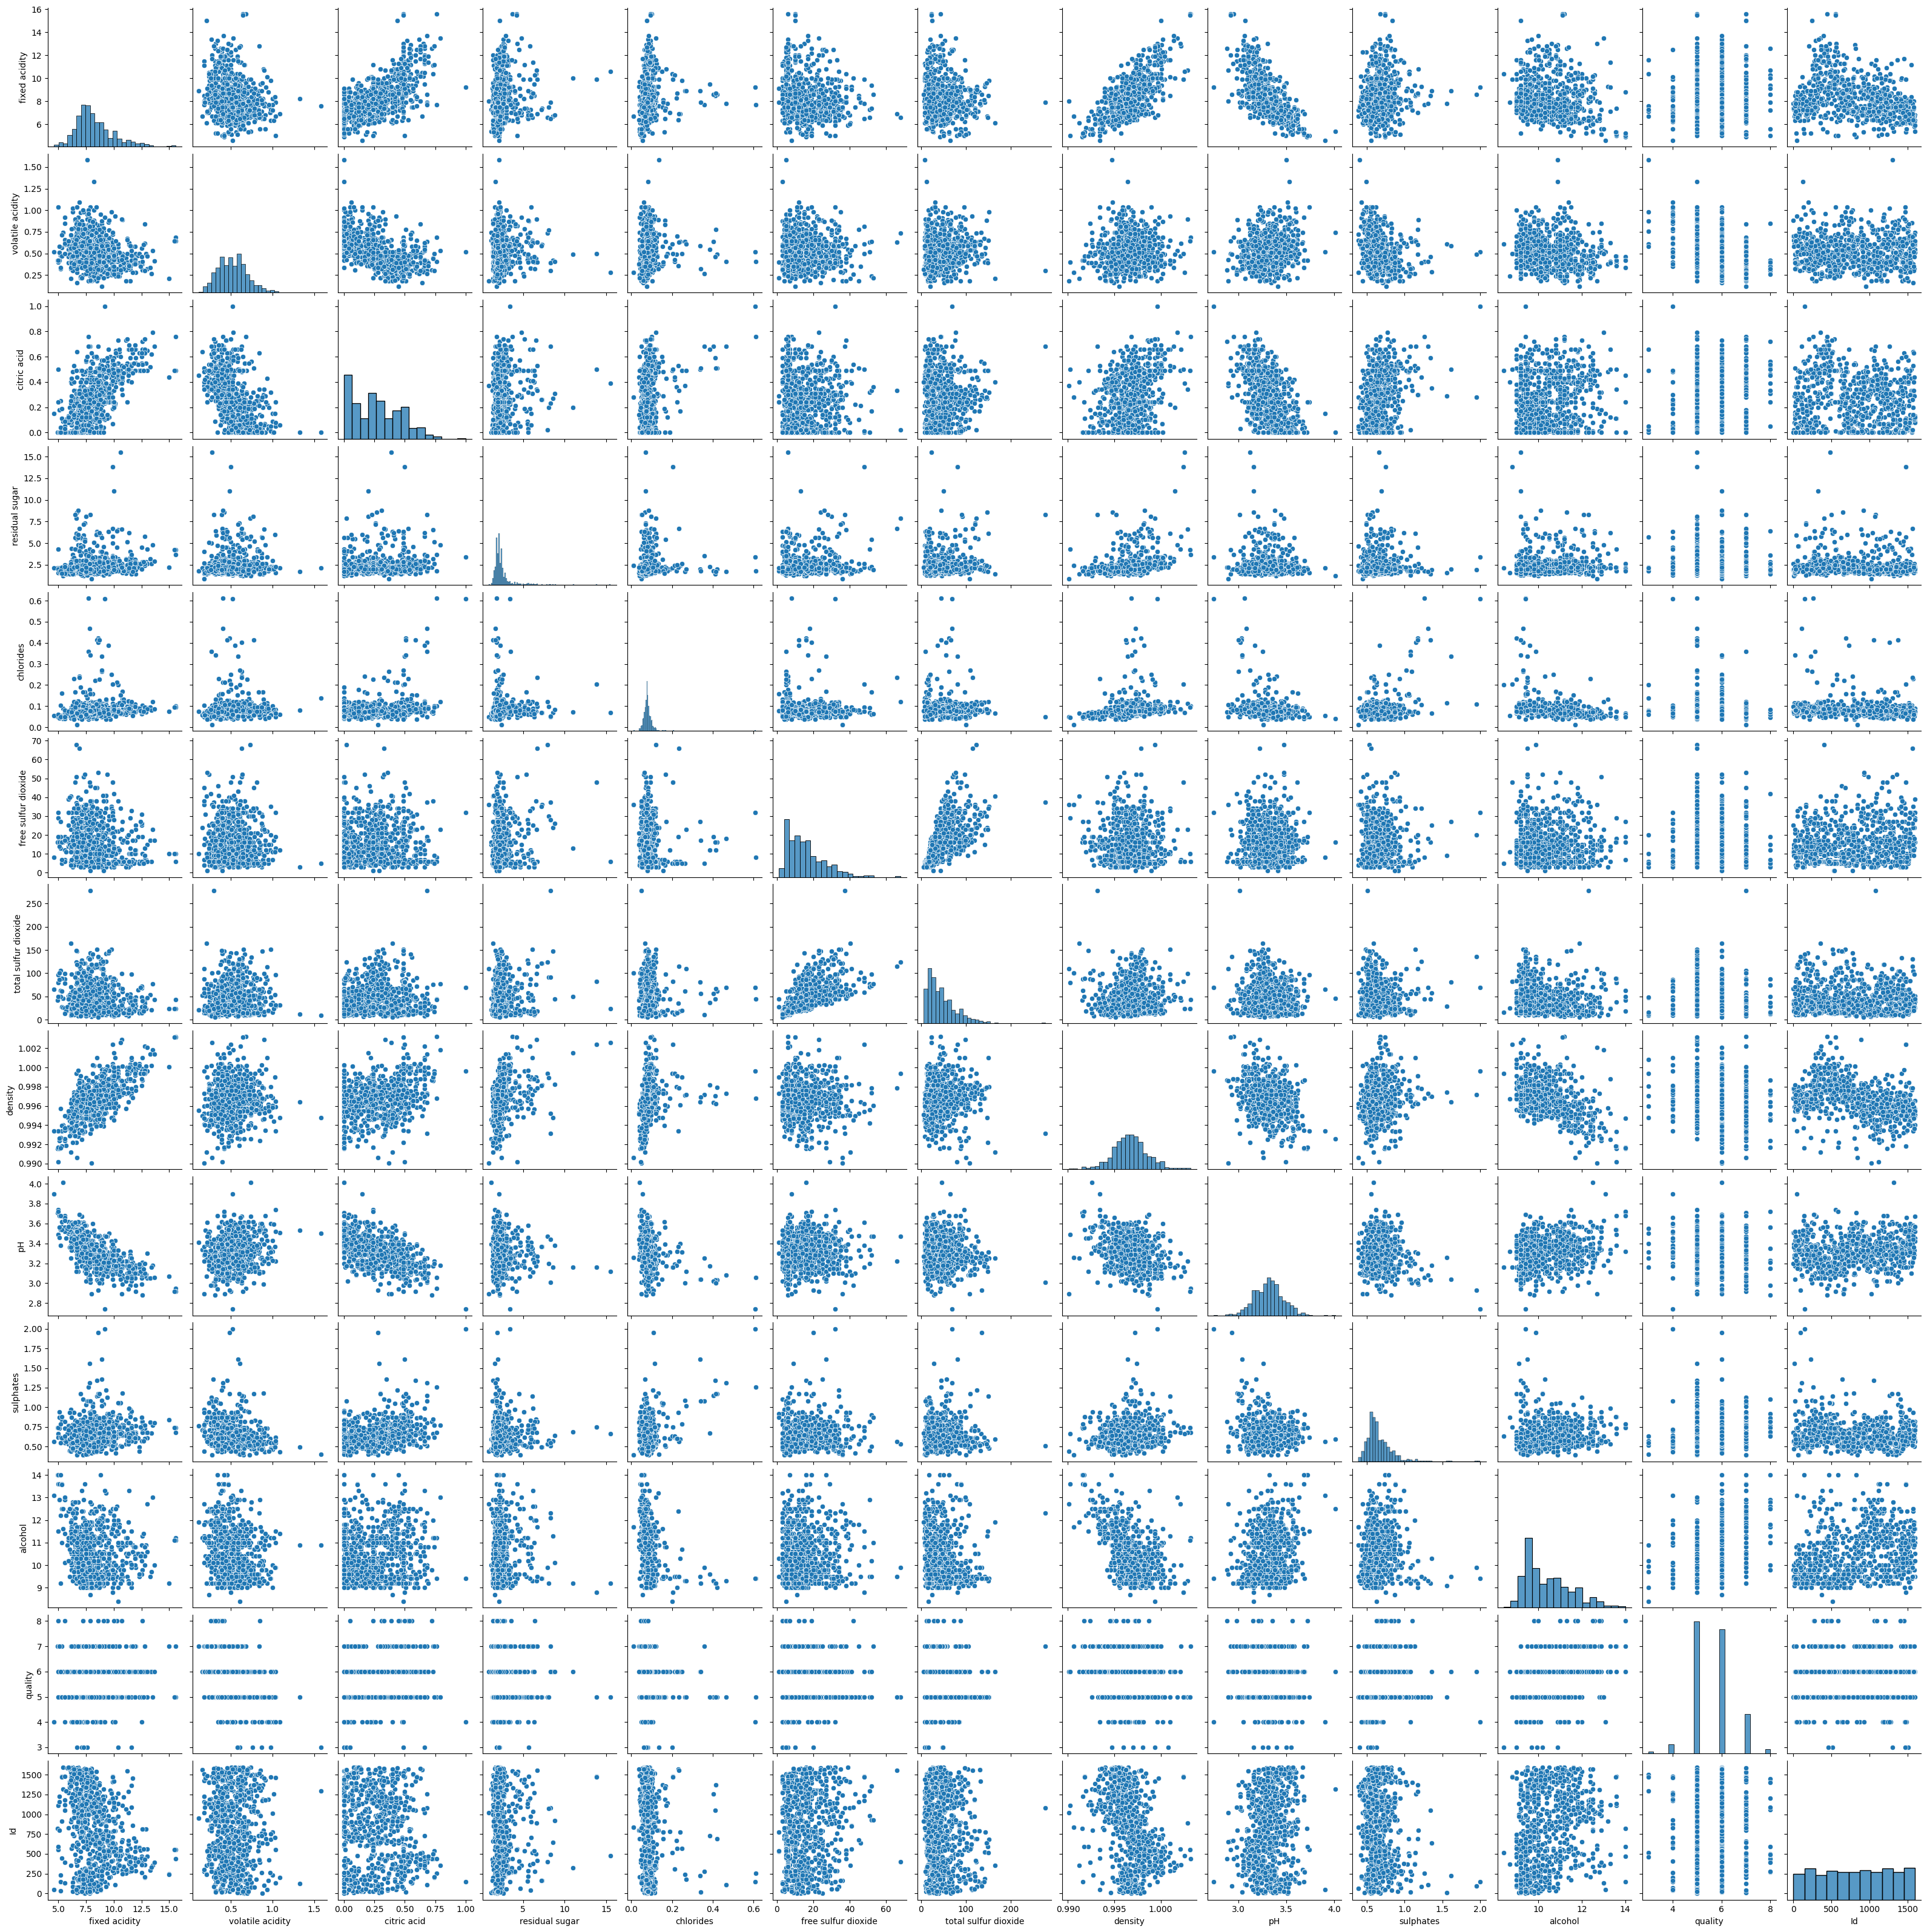

Korelasi Fitur terhadap Quality
quality                 1.000000
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
Id                      0.049030
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059
Name: quality, dtype: float64


In [19]:
# ================================
# VISUALISASI DATA SETELAH CLEANING
# ================================

# ================================
# CEK KEMBALI MISSING VALUE
# ================================

print("MISSING VALUE SETELAH CLEANING")

print(train_df.isnull().sum())

# ================================
# VISUALISASI MISSING VALUE
# ================================

plt.figure(figsize=(10,6))

sns.heatmap(
    train_df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Value Setelah Cleaning')

plt.show()

# ================================
# HISTOGRAM SETELAH CLEANING
# ================================

train_df.hist(figsize=(15,12))

plt.suptitle('Histogram Setelah Data Cleaning')

plt.show()

# ================================
# BOXPLOT SETELAH CLEANING
# ================================

plt.figure(figsize=(15,8))

train_df.boxplot()

plt.xticks(rotation=90)

plt.title('Boxplot Setelah Data Cleaning')

plt.show()

# ================================
# DISTRIBUSI TARGET QUALITY
# ================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='quality',
    data=train_df
)

plt.title('Distribusi Quality Setelah Cleaning')

plt.show()

# ================================
# HEATMAP KORELASI
# ================================

plt.figure(figsize=(12,8))

sns.heatmap(
    train_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix Setelah Cleaning')

plt.show()

# ================================
# PAIRPLOT
# ================================

sns.pairplot(train_df)

plt.show()

# ================================
# KORELASI TERHADAP TARGET
# ================================

correlation = train_df.corr()['quality'].sort_values(ascending=False)

print("Korelasi Fitur terhadap Quality")

print(correlation)

Visualisasi ulang dilakukan setelah data cleaning untuk memastikan bahwa missing value telah berhasil ditangani dan data siap digunakan untuk modeling.

Pada tahap ini:

heatmap missing value menunjukkan dataset sudah bersih,
histogram menunjukkan distribusi data setelah cleaning,
boxplot membantu melihat keberadaan outlier,
heatmap korelasi menunjukkan hubungan antar variabel,
pairplot membantu melihat pola hubungan antar fitur,
korelasi terhadap quality menunjukkan fitur mana yang paling berpengaruh terhadap kualitas wine.

Tahap ini membantu memahami pola data yang akan dipelajari oleh model machine learning.

# **PREPROCESSING**

In [22]:
# ================================
# PREPROCESSING
# ================================

# Memisahkan fitur dan target
X = train_df.drop(['Id', 'quality'], axis=1)

y = train_df['quality']

# Melihat bentuk data
print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (857, 11)
Shape y : (857,)


Dataset dipisahkan menjadi:

fitur/input (X)
target/output (y)

Kolom quality dijadikan target prediksi karena tujuan utama penelitian adalah memprediksi kualitas wine. Sedangkan kolom Id dihapus karena hanya berfungsi sebagai identitas data dan tidak mempengaruhi prediksi.

Tahap ini penting karena model machine learning membutuhkan pemisahan antara input dan output.

In [23]:
# Membagi data training dan validation

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Melihat ukuran data
print("X_train :", X_train.shape)
print("X_val :", X_val.shape)
print("y_train :", y_train.shape)
print("y_val :", y_val.shape)

X_train : (685, 11)
X_val : (172, 11)
y_train : (685,)
y_val : (172,)


Interpretasi

Dataset berhasil dibagi menjadi:

data training (80%)
data validation (20%)

Data training digunakan untuk melatih model, sedangkan data validation digunakan untuk menguji kemampuan model dalam memprediksi data baru.

Penggunaan validation data penting untuk mengetahui apakah model mengalami overfitting atau tidak.

In [24]:
# Membuat object scaler
scaler = StandardScaler()

# Scaling data training
X_train_scaled = scaler.fit_transform(X_train)

# Scaling data validation
X_val_scaled = scaler.transform(X_val)

Feature scaling dilakukan menggunakan StandardScaler agar seluruh fitur memiliki skala yang sama. Hal ini penting karena setiap fitur memiliki rentang nilai yang berbeda-beda.

Dengan scaling:

model dapat bekerja lebih optimal,
proses training menjadi lebih stabil,
dan fitur dengan nilai besar tidak mendominasi fitur lain.

Data training dilakukan fit_transform() sedangkan validation data menggunakan transform() agar konsisten.

In [26]:
# Menghapus kolom id dari data testing
X_test = test_df.drop('Id', axis=1)

# Scaling data testing
X_test_scaled = scaler.transform(X_test)

# Melihat ukuran data testing
print("Shape X_test :", X_test.shape)

Shape X_test : (286, 11)


## **MODEL**

In [27]:
# ================================
# MODELING
# ================================

# Membuat model Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

Pada tahap ini dibuat model klasifikasi menggunakan algoritma Random Forest.

Random Forest dipilih karena:

mampu menangani data numerik dengan baik,
memiliki akurasi yang cukup tinggi,
dan mampu mengurangi overfitting dibanding decision tree biasa.

Parameter n_estimators=200 menunjukkan bahwa model menggunakan 200 decision tree dalam proses klasifikasi.

In [28]:
# Training model menggunakan data training

model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Model berhasil dilatih menggunakan data training melalui fungsi fit().

Pada tahap ini model mulai mempelajari pola hubungan antara fitur-fitur kimia wine dengan target quality sehingga nantinya model dapat digunakan untuk melakukan prediksi pada data baru.

In [29]:
# Melihat fitur yang paling berpengaruh

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Mengurutkan dari terbesar
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
10               alcohol    0.139281
9              sulphates    0.122799
1       volatile acidity    0.110338
6   total sulfur dioxide    0.105630
7                density    0.084770
4              chlorides    0.080142
8                     pH    0.077190
2            citric acid    0.074695
0          fixed acidity    0.074188
3         residual sugar    0.066638
5    free sulfur dioxide    0.064328


Feature importance digunakan untuk mengetahui fitur mana yang paling berpengaruh terhadap prediksi kualitas wine.

Semakin tinggi nilai importance suatu fitur maka semakin besar kontribusinya terhadap hasil prediksi model.

Tahap ini membantu memahami faktor-faktor utama yang mempengaruhi kualitas wine.

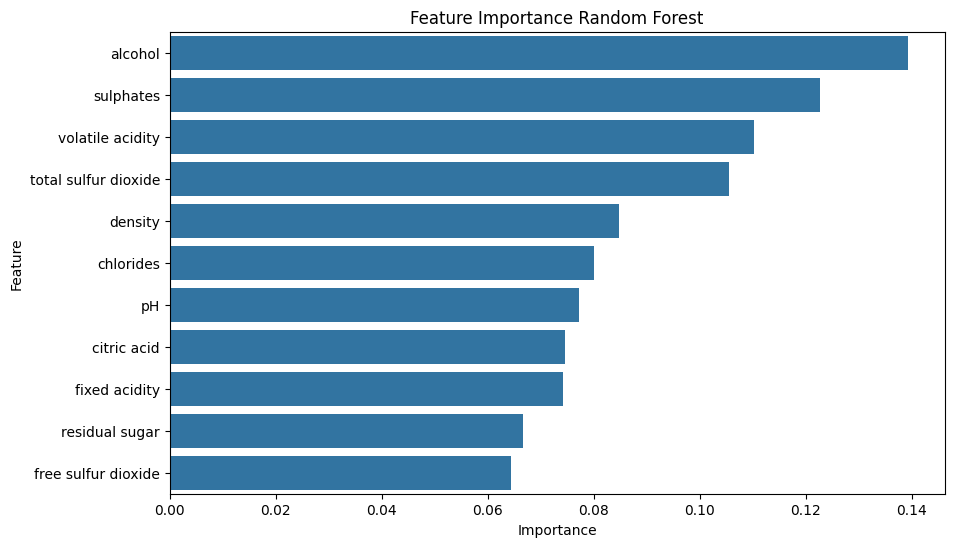

In [30]:
# Visualisasi feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance Random Forest')

plt.show()

Visualisasi feature importance dalam bentuk barplot mempermudah identifikasi fitur yang paling berpengaruh terhadap kualitas wine.

Grafik ini membantu memahami bagaimana model Random Forest mengambil keputusan dalam proses klasifikasi.

In [31]:
# ================================
# EVALUATION
# ================================

# Prediksi data validation

y_pred = model.predict(X_val_scaled)

Model melakukan prediksi pada data validation yang sebelumnya tidak digunakan dalam training.

Tahap ini digunakan untuk menguji kemampuan generalisasi model terhadap data baru.

In [32]:
# Menghitung accuracy

accuracy = accuracy_score(y_val, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.6162790697674418


Nilai accuracy menunjukkan tingkat ketepatan model dalam melakukan klasifikasi kualitas wine.

Semakin tinggi nilai accuracy maka semakin baik performa model dalam memprediksi kualitas wine dengan benar.

Accuracy digunakan sebagai indikator utama performa model pada penelitian ini.

In [33]:
# Menampilkan classification report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.64      0.67      0.66        67
           6       0.60      0.68      0.64        78
           7       0.57      0.38      0.46        21
           8       0.00      0.00      0.00         3

    accuracy                           0.62       172
   macro avg       0.36      0.35      0.35       172
weighted avg       0.59      0.62      0.60       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification report memberikan evaluasi lebih detail terhadap performa model melalui:

precision,
recall,
dan f1-score.

Nilai tersebut menunjukkan kemampuan model dalam mengenali masing-masing kelas quality wine.

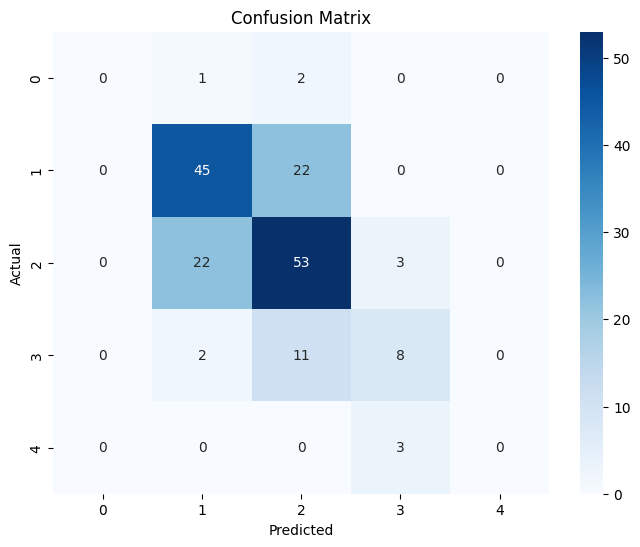

In [34]:
# Membuat confusion matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

Confusion matrix menunjukkan jumlah prediksi benar dan salah pada tiap kelas quality wine.

Nilai diagonal yang tinggi menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar oleh model.

Visualisasi heatmap mempermudah analisis performa model pada tiap kategori quality.

In [35]:
# ================================
# PREDICTION
# ================================

# Prediksi data testing

predictions = model.predict(X_test_scaled)

Model berhasil digunakan untuk memprediksi kualitas wine pada dataset testing berdasarkan pola yang telah dipelajari sebelumnya.

Tahap ini merupakan tujuan utama dari proses data mining yang dilakukan.

In [36]:
# Menampilkan hasil prediksi

predictions

array([5, 5, 5, 5, 5, 6, 5, 5, 6, 5, 7, 6, 6, 6, 5, 5, 6, 5, 5, 7, 6, 7,
       5, 7, 5, 5, 6, 6, 5, 6, 5, 6, 7, 6, 5, 5, 6, 6, 7, 5, 7, 5, 7, 5,
       5, 5, 5, 6, 5, 6, 7, 5, 6, 7, 6, 7, 6, 6, 6, 5, 5, 6, 6, 6, 6, 6,
       6, 5, 5, 5, 7, 5, 5, 6, 5, 5, 5, 6, 5, 6, 5, 6, 6, 5, 5, 6, 5, 6,
       6, 6, 5, 6, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 5, 6, 5, 5, 6, 6, 6, 6,
       7, 5, 5, 6, 5, 5, 6, 6, 5, 5, 5, 5, 5, 6, 5, 6, 6, 6, 5, 6, 5, 5,
       7, 6, 7, 5, 5, 5, 6, 6, 6, 5, 5, 5, 6, 5, 5, 5, 5, 5, 6, 5, 6, 5,
       6, 5, 5, 5, 7, 6, 5, 5, 6, 6, 7, 5, 6, 6, 6, 5, 6, 6, 6, 5, 5, 5,
       7, 5, 6, 5, 6, 5, 6, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 6, 6, 5, 6,
       7, 6, 6, 6, 5, 6, 6, 7, 5, 5, 6, 6, 5, 6, 5, 6, 5, 6, 6, 5, 6, 5,
       6, 6, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 5, 5, 6, 7, 5, 6, 6, 5, 7, 6,
       6, 5, 5, 6, 5, 6, 5, 5, 5, 5, 6, 6, 5, 6, 7, 5, 5, 5, 6, 6, 7, 6,
       5, 5, 5, 6, 5, 6, 6, 7, 5, 6, 5, 6, 5, 6, 5, 5, 5, 5, 5, 5, 5, 7])

In [38]:
# ================================
# EXPORT CSV
# ================================

hasil = pd.DataFrame({
    'id': test_df['Id'],
    'quality': predictions
})

Hasil prediksi disusun dalam format submission yang terdiri dari:

kolom id,
dan kolom quality.

Format ini digunakan agar hasil prediksi siap disimpan dalam file CSV.

In [44]:
# ================================
# PREDICTION
# ================================

# Melakukan prediksi pada data testing
predictions = model.predict(X_test_scaled)

# ================================
# MEMBUAT DATAFRAME SUBMISSION
# ================================

submission = pd.DataFrame({
    'id': test_df['Id'],
    'quality': predictions
})

# ================================
# MENAMPILKAN 200 DATA PERTAMA
# ================================

display(submission.head(200))

# ================================
# MENYIMPAN FILE SUBMISSION CSV
# ================================

submission.to_csv(
    'submission.csv',
    index=False
)

print("File submission berhasil disimpan")

# ================================
# DOWNLOAD FILE SUBMISSION
# ================================

from google.colab import files

files.download('submission.csv')

,id,quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,5
...,...,...
195,749,6
196,1553,5
197,1036,6
198,1107,7


File submission berhasil disimpan


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


Tahap terakhir berhasil membuat file submission.csv yang berisi hasil prediksi kualitas wine.